In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Размер датасета: (1000, 21)

Первые 5 строк:
   default account_check_status  duration_in_month  \
0        0               < 0 DM                  6   
1        1    0 <= ... < 200 DM                 48   
2        0  no checking account                 12   
3        0               < 0 DM                 42   
4        1               < 0 DM                 24   

                                      credit_history  \
0  critical account/ other credits existing (not ...   
1           existing credits paid back duly till now   
2  critical account/ other credits existing (not ...   
3           existing credits paid back duly till now   
4                    delay in paying off in the past   

                        purpose  credit_amount                      savings  \
0           domestic appliances           1169  unknown/ no savings account   
1           domestic appliances           5951                 ... < 100 DM   
2  (vacation - does not exist?)           2096          

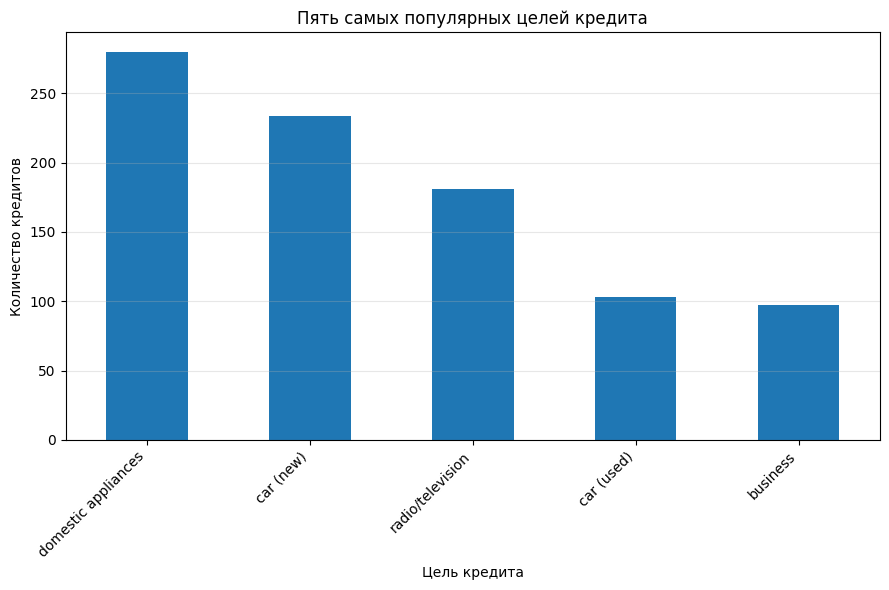


Распределение по полу:
personal_status_sex
male      690
female    310
Name: count, dtype: int64

Количество столбцов после One-Hot Encoding:
25

Средняя сумма кредита у хороших заёмщиков:
2985.46

Средняя сумма кредита у плохих заёмщиков:
3938.13


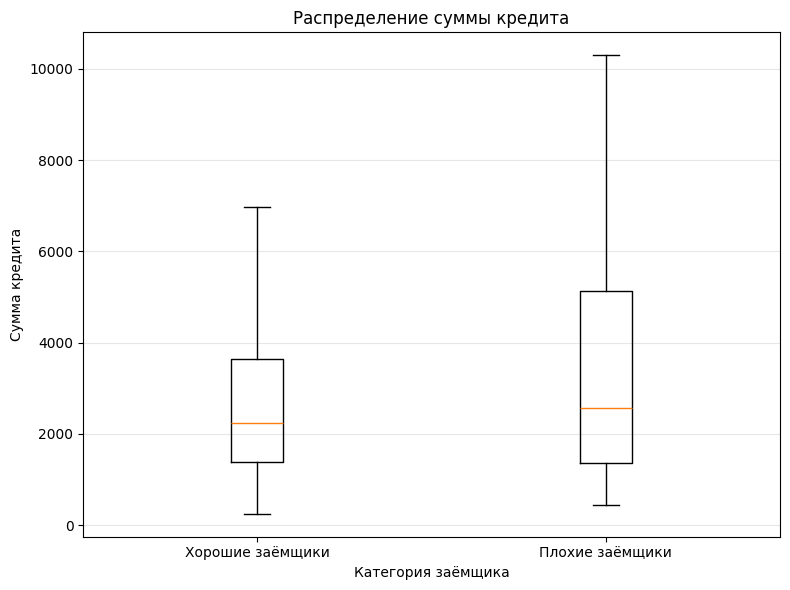


Средний возраст и срок кредита по кредитной истории:
                                                    Средний возраст  \
credit_history                                                        
all credits at this bank paid back duly                       36.27   
critical account/ other credits existing (not a...            38.44   
delay in paying off in the past                               36.14   
existing credits paid back duly till now                      33.88   
no credits taken/ all credits paid back duly                  34.30   

                                                    Средний срок кредита  
credit_history                                                            
all credits at this bank paid back duly                            22.69  
critical account/ other credits existing (not a...                 19.49  
delay in paying off in the past                                    26.22  
existing credits paid back duly till now                           20.11 

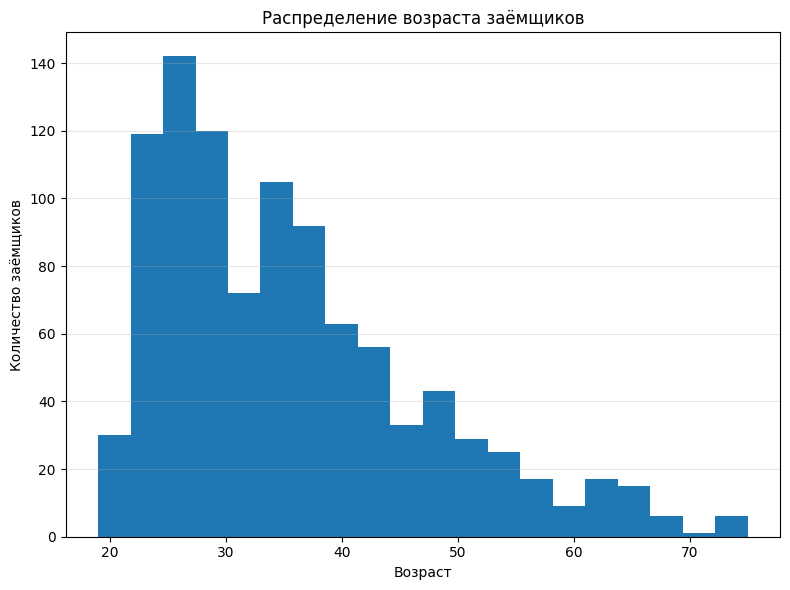

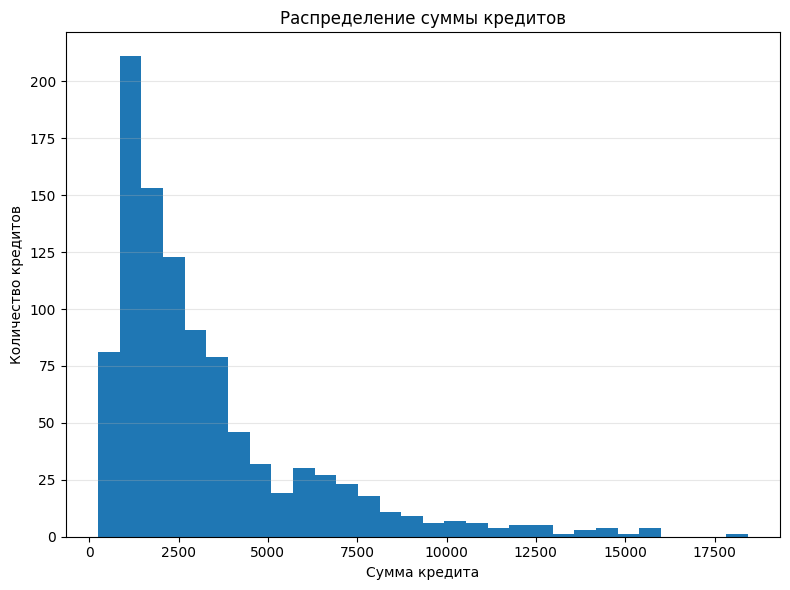

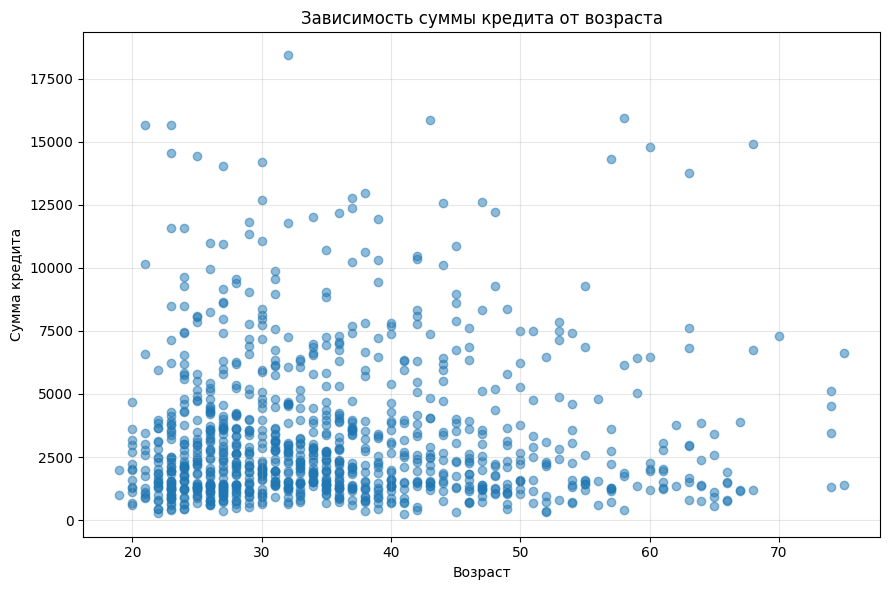

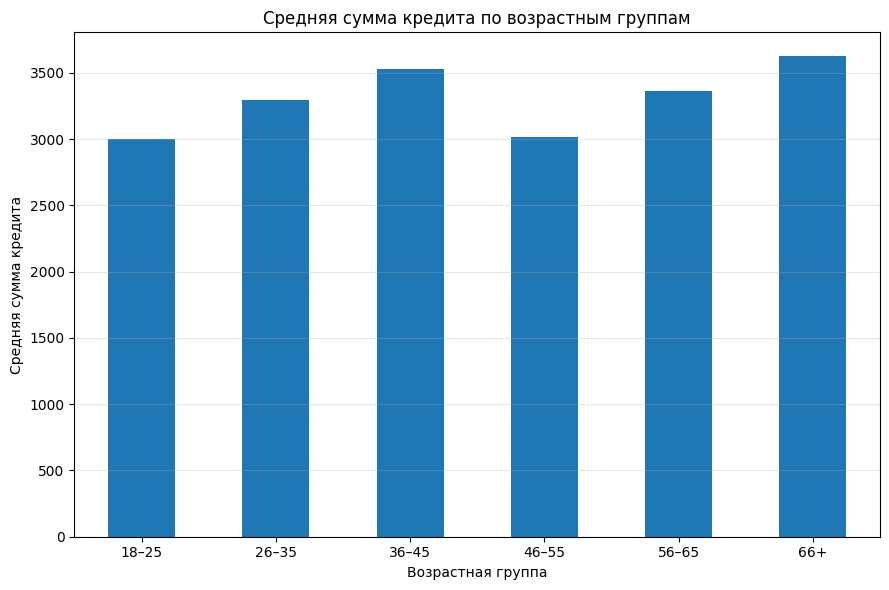


Матрица корреляции:
               Возраст  Сумма кредита  Срок кредита
Возраст          1.000          0.033        -0.036
Сумма кредита    0.033          1.000         0.625
Срок кредита    -0.036          0.625         1.000

Выводы по графикам:
1. Большая часть заёмщиков имеет возраст примерно от 20 до 40 лет.
2. Большинство кредитов имеют относительно небольшую сумму, при этом встречаются кредиты значительно большей стоимости.
3. На диаграмме рассеяния не наблюдается явно выраженной линейной зависимости между возрастом заёмщика и суммой кредита.

Итоговая информация:
Количество строк: 1000
Количество исходных столбцов: 21
Количество пропусков: 0
Обработка данных завершена.


In [6]:
# Импортируем необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Загружаем датасет
df = pd.read_csv("german_credit.csv")

print("Размер датасета:", df.shape)

print("\nПервые 5 строк:")
print(df.head())


# Проверяем информацию о датасете
print("\nИнформация о датасете:")
df.info()


# Проверяем наличие пропусков
print("\nКоличество пропусков:")

for column in df.columns:
    print(f"{column}: {df[column].isnull().sum()}")


# Выбираем числовые столбцы
numeric_columns = df.select_dtypes(include=np.number).columns


# Рассчитываем основные статистические показатели
print("\nСредние значения:")
print(df[numeric_columns].mean().round(2))

print("\nМедианные значения:")
print(df[numeric_columns].median().round(2))

print("\nСтандартное отклонение:")
print(df[numeric_columns].std().round(2))


# Обрабатываем пропуски в числовых столбцах
for column in df.select_dtypes(include=np.number).columns:
    df[column] = df[column].fillna(df[column].median())


# Обрабатываем пропуски в текстовых столбцах
for column in df.select_dtypes(exclude=np.number).columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].mode()[0])


print("\nКоличество пропусков после обработки:")
print(df.isnull().sum().sum())


# Находим пять самых популярных целей кредита
purpose_counts = df["purpose"].value_counts()
top_5_purposes = purpose_counts.head(5)

print("\nПять самых популярных целей кредита:")
print(top_5_purposes)


# Строим график популярных целей кредита
plt.figure(figsize=(9, 6))

top_5_purposes.plot(kind="bar")

plt.title("Пять самых популярных целей кредита")
plt.xlabel("Цель кредита")
plt.ylabel("Количество кредитов")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# Извлекаем пол из столбца personal_status_sex
sex = df["personal_status_sex"].str.split(" : ").str[0]

print("\nРаспределение по полу:")
print(sex.value_counts())


# Выполняем One-Hot Encoding для пола и типа жилья
df_encoded = df.copy()
df_encoded["sex"] = sex

df_encoded = pd.get_dummies(
    df_encoded,
    columns=["sex", "housing"],
    dtype=int
)

print("\nКоличество столбцов после One-Hot Encoding:")
print(df_encoded.shape[1])


# Разделяем заёмщиков на хорошие и плохие группы
good_credit = df[df["default"] == 0]["credit_amount"]
bad_credit = df[df["default"] == 1]["credit_amount"]

print("\nСредняя сумма кредита у хороших заёмщиков:")
print(round(good_credit.mean(), 2))

print("\nСредняя сумма кредита у плохих заёмщиков:")
print(round(bad_credit.mean(), 2))


# Сравниваем суммы кредитов с помощью box plot
plt.figure(figsize=(8, 6))

plt.boxplot(
    [good_credit, bad_credit],
    tick_labels=[
        "Хорошие заёмщики",
        "Плохие заёмщики"
    ],
    showfliers=False
)

plt.title("Распределение суммы кредита")
plt.xlabel("Категория заёмщика")
plt.ylabel("Сумма кредита")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# Создаём сводную таблицу по кредитной истории
pivot_table = pd.pivot_table(
    df,
    values=["age", "duration_in_month"],
    index="credit_history",
    aggfunc="mean"
)

pivot_table = pivot_table.rename(
    columns={
        "age": "Средний возраст",
        "duration_in_month": "Средний срок кредита"
    }
)

print("\nСредний возраст и срок кредита по кредитной истории:")
print(pivot_table.round(2))


# Нормализуем возраст, сумму кредита и срок кредита
df_normalized = df.copy()

columns_to_normalize = [
    "age",
    "credit_amount",
    "duration_in_month"
]

for column in columns_to_normalize:
    min_value = df_normalized[column].min()
    max_value = df_normalized[column].max()

    df_normalized[column] = (
        (df_normalized[column] - min_value)
        / (max_value - min_value)
    )


print("\nПервые нормализованные значения:")

print("\nВозраст:")
print(
    df_normalized["age"]
    .head()
    .round(3)
    .to_string(index=False)
)

print("\nСумма кредита:")
print(
    df_normalized["credit_amount"]
    .head()
    .round(3)
    .to_string(index=False)
)

print("\nСрок кредита:")
print(
    df_normalized["duration_in_month"]
    .head()
    .round(3)
    .to_string(index=False)
)


# Строим гистограмму возраста
plt.figure(figsize=(8, 6))

plt.hist(
    df["age"],
    bins=20
)

plt.title("Распределение возраста заёмщиков")
plt.xlabel("Возраст")
plt.ylabel("Количество заёмщиков")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# Строим гистограмму суммы кредита
plt.figure(figsize=(8, 6))

plt.hist(
    df["credit_amount"],
    bins=30
)

plt.title("Распределение суммы кредитов")
plt.xlabel("Сумма кредита")
plt.ylabel("Количество кредитов")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# Показываем зависимость суммы кредита от возраста
plt.figure(figsize=(9, 6))

plt.scatter(
    df["age"],
    df["credit_amount"],
    alpha=0.5
)

plt.title("Зависимость суммы кредита от возраста")
plt.xlabel("Возраст")
plt.ylabel("Сумма кредита")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Создаём возрастные группы отдельно от исходного датасета
age_groups = pd.cut(
    df["age"],
    bins=[18, 25, 35, 45, 55, 65, 100],
    labels=[
        "18–25",
        "26–35",
        "36–45",
        "46–55",
        "56–65",
        "66+"
    ]
)


# Рассчитываем среднюю сумму кредита для каждой возрастной группы
average_credit_by_age = df.groupby(
    age_groups,
    observed=False
)["credit_amount"].mean()


# Строим график средней суммы кредита
plt.figure(figsize=(9, 6))

average_credit_by_age.plot(kind="bar")

plt.title("Средняя сумма кредита по возрастным группам")
plt.xlabel("Возрастная группа")
plt.ylabel("Средняя сумма кредита")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# Рассчитываем корреляцию между числовыми признаками
correlation = df[
    [
        "age",
        "credit_amount",
        "duration_in_month"
    ]
].corr()

correlation = correlation.rename(
    index={
        "age": "Возраст",
        "credit_amount": "Сумма кредита",
        "duration_in_month": "Срок кредита"
    },
    columns={
        "age": "Возраст",
        "credit_amount": "Сумма кредита",
        "duration_in_month": "Срок кредита"
    }
)

print("\nМатрица корреляции:")
print(correlation.round(3))


# Делаем выводы по графикам
print("\nВыводы по графикам:")

print(
    "1. Большая часть заёмщиков имеет возраст примерно от 20 до 40 лет."
)

print(
    "2. Большинство кредитов имеют относительно небольшую сумму, "
    "при этом встречаются кредиты значительно большей стоимости."
)

print(
    "3. На диаграмме рассеяния не наблюдается явно выраженной "
    "линейной зависимости между возрастом заёмщика и суммой кредита."
)


# Выводим итоговую информацию
print("\nИтоговая информация:")
print("Количество строк:", df.shape[0])
print("Количество исходных столбцов:", 21)
print("Количество пропусков:", df.isnull().sum().sum())
print("Обработка данных завершена.")